# Загрузка данных

In [1]:
from pathlib import Path
import pandas as pd
import json

In [2]:
BASE_DIR = Path.cwd()
json_path = BASE_DIR / 'data' / 'arxiv-metadata-s.json'
csv_path = BASE_DIR / 'data' / 'test_sample.csv'

print(f"JSON: {json_path.resolve()}")
print(f"CSV:  {csv_path.resolve()}")

JSON: /home/ubuntu/Retrieval-system--arXiv/data/arxiv-metadata-s.json
CSV:  /home/ubuntu/Retrieval-system--arXiv/data/test_sample.csv


In [3]:
with open(json_path, 'r', encoding='utf-8') as f:
        corpus_df = pd.json_normalize(json.load(f))
test_df = pd.read_csv(csv_path)

# Этап 1. Исследовательский анализ (EDA)

In [4]:
import matplotlib.pyplot as plt

In [5]:
print("📊 Corpus shape:", corpus_df.shape)
corpus_df.head()

📊 Corpus shape: (98213, 14)


,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,0704.0038,Maxim A. Yurkin,"Maxim A. Yurkin, Alfons G. Hoekstra",The discrete dipole approximation: an overview...,"36 pages, 1 figure; added several corrections ...","J.Quant.Spectrosc.Radiat.Transf. 106, 558-589 ...",10.1016/j.jqsrt.2007.01.034 10.1016/j.jqsrt.20...,None,physics.optics physics.comp-ph,http://creativecommons.org/licenses/by-nc-nd/4.0/,We present a review of the discrete dipole a...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2022-03-30,"[[Yurkin, Maxim A., ], [Hoekstra, Alfons G., ]]"
1,0704.0057,Philipp Werner,Philipp Werner and Andrew J. Millis,High-spin to low-spin and orbital polarization...,Published version,"Phys. Rev. Lett. 99, 126405 (2007)",10.1103/PhysRevLett.99.126405,None,cond-mat.str-el,None,We study the interplay of crystal field spli...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2009-11-13,"[[Werner, Philipp, ], [Millis, Andrew J., ]]"
2,0704.0060,Carlos Bertulani,"C.A. Bertulani, G. Cardella, M. De Napoli, G. ...",Coulomb excitation of unstable nuclei at inter...,"12 pages, 2 figures, accepted for publication ...","Phys.Lett.B650:233-238,2007",10.1016/j.physletb.2007.05.029,None,nucl-th,None,We investigate the Coulomb excitation of low...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2008-11-26,"[[Bertulani, C. A., ], [Cardella, G., ], [De N..."
3,0704.0070,Yanzhang He,He Yanzhang and Bao Chengguang,Coincidence of the oscillations in the dipole ...,"5 pages, 4 figures, submitted",J. Phys.: Condens. Matter 20 (2008) 055214,None,None,cond-mat.mes-hall,None,The fractional Aharonov-Bohm oscillation (FA...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2008-01-19,"[[Yanzhang, He, ], [Chengguang, Bao, ]]"
4,0704.0074,Jawad Y. Abuhlail,"J. Y. Abuhlail, S. K. Nauman",Injective Morita contexts (revisited),None,None,None,None,math.RA,None,This paper is an exposition of the so-called...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2007-08-22,"[[Abuhlail, J. Y., ], [Nauman, S. K., ]]"


In [6]:
print("📊 Test shape:", test_df.shape)
test_df.head()

📊 Test shape: (1000, 3)


,id,abstract,query
0,2412.16732,A new platinate was recently discovered when...,What unique composition and decomposition beha...
1,nucl-th/9602019,The production cross sections of various fra...,How does the inclusion of statistical decay af...
2,2501.05500,This survey provides a comprehensive examina...,What are the core components of modern zero-kn...
3,2506.20892,A critical challenge for operating fusion burn...,How does impurity seeding affect the timing an...
4,2208.02031,"In this work, we present the first corpus fo...",What is the primary challenge of the newly dev...


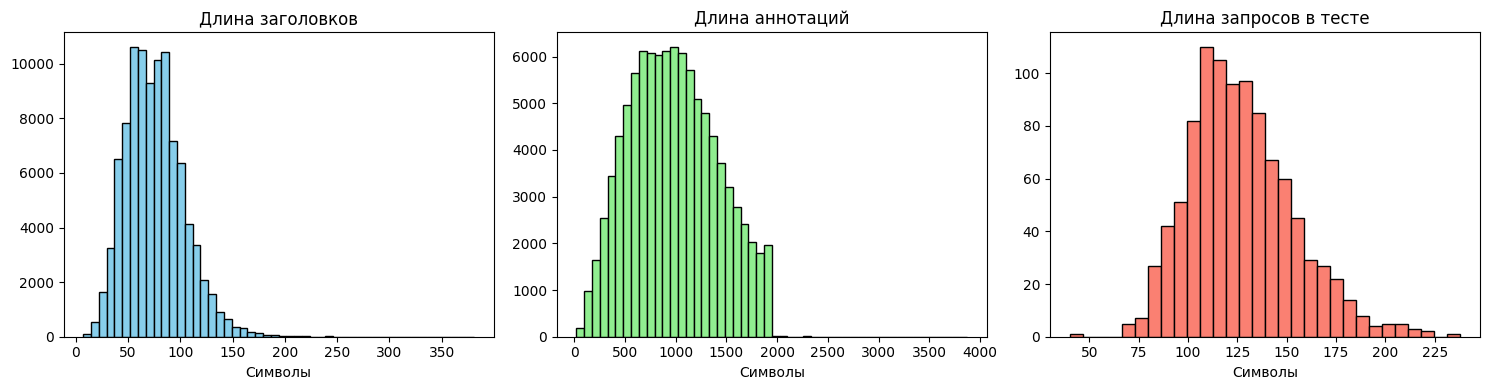

Missing values in corpus:
title       0
abstract    0
dtype: int64

Overlap test IDs in corpus: 1000 / 1000


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Длина заголовков
corpus_df['title_len'] = corpus_df['title'].astype(str).str.len()
axes[0].hist(corpus_df['title_len'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Длина заголовков')
axes[0].set_xlabel('Символы')

# Длина аннотаций
corpus_df['abstract_len'] = corpus_df['abstract'].astype(str).str.len()
axes[1].hist(corpus_df['abstract_len'], bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Длина аннотаций')
axes[1].set_xlabel('Символы')

# Длина запросов в тесте
test_df['query_len'] = test_df['query'].astype(str).str.len()
axes[2].hist(test_df['query_len'], bins=30, color='salmon', edgecolor='black')
axes[2].set_title('Длина запросов в тесте')
axes[2].set_xlabel('Символы')

plt.tight_layout()
plt.show()

print("Missing values in corpus:")
print(corpus_df[['title', 'abstract']].isnull().sum())
print("\nOverlap test IDs in corpus:", test_df['id'].isin(corpus_df['id']).sum(), "/", len(test_df))

## Выводы


### Анализ данных
- **Заголовки:** большинство 50-100 символов, распределение близкое к нормальному
- **Аннотации:** типичная длина 500-1500 символов, пик ~1000 символов
- **Запросы:** короче аннотаций, пик 100-125 символов, есть более длинные до 225 символов
- **Качество данных:** пропусков нет, все тестовые статьи присутствуют в корпусе (1000/1000)

**Вывод:** данные чистые, готовы к работе


### Выбор модели


| Ограничение | Влияние на решение |
|-------------|-------------------|
| **Время выполнения** | Не используем тяжелые модели (>500MB) |
| **Отсутствие GPU** | Выбираем модели, оптимизированные для CPU |
| **Размер корпуса** | ~1000-10000 статей — можно хранить все эмбеддинги в памяти |
| **MRR@5 > 0.91** | Нужна хорошая семантическая модель, не просто keywords |
| **Простота реализации** | Используем готовые библиотеки (sentence-transformers) |


**Модель:** SentenceTransformer

**Кандидаты:**
- all-MiniLM-L6-v2 (80MB, 384 dim) — быстро, хорошая точность
- paraphrase-MiniLM-L6-v2 (80MB, 384 dim) — лучше для перефразировок
- all-mpnet-base-v2 (420MB, 768 dim) — точнее, но медленнее
- specter (440MB, 768 dim) — специализирована для научных статей

**Выбор:** all-MiniLM-L6-v2

**Почему:**
- Оптимальный баланс скорость/точность
- Работает на CPU без GPU
- Малый размер (~80MB) — быстрая загрузка
- Достаточно 384 измерений для качественного поиска
- Хорошо обучена на разнообразных текстах


### Подход к решению задачи

#### 1. Векторная база данных (Qdrant с индексом HNSW)
*   **Что:** Хранилище векторов (эмбеддингов) статей arXiv.
*   **Почему:** Хочется разобраться с Qdrant + это хорошая БД для дальнейшего масштабирования, в том числе с потенциалом переноса БД в облако. Индекс **HNSW** позволяет искать ближайшие векторы за доли миллисекунды, избегая медленного перебора всей базы (O(log n) вместо O(n)).

#### 2. Модель первого этапа: Bi-Encoder (`all-MiniLM-L6-v2`)
*   **Что:** Легкая модель, преобразующая текст запроса в вектор для поиска в Qdrant.
*   **Почему:** Нужна **скорость**. Она быстро находит 50 наиболее похожих статей по смыслу, отсеивая абсолютный шум, но может упускать тонкие детали.

#### 3. Модель второго этапа: Cross-Encoder (`cross-encoder/ms-marco-MiniLM-L-6-v2`)
*   **Что:** Модель, которая получает пару «запрос — текст статьи» и выдает точный балл релевантности.
*   **Почему:** Нужна **точность (MRR)**. Она понимает контекст лучше, чем Bi-Encoder. Переранжируя только 50 кандидатов (а не всю базу), она дает прирост качества почти без потери времени.

#### 4. Логика оценки и профилирования
*   **Что:** Скрипт, соединяющий поиск и расчет метрик (MRR@5, время выполнения).
*   **Почему:** Необходимо для доказательства выполнения задания (MRR > 0.91) и поиска «узких мест» в производительности.

# Этап 2. Реализация retrieval-системы

## Подготовка данных

In [8]:
# Формируем текст для эмбеддинга
corpus_df['search_text'] = (
    corpus_df['title'].fillna('') + ' | ' + corpus_df['abstract'].fillna('')
).str.strip()

In [9]:
# Убираем совсем короткие/пустые записи
corpus_df = corpus_df[corpus_df['search_text'].str.len() > 20].reset_index(drop=True)

## Загрузка моделей и инициализация Qdrant

In [10]:
import time
from tqdm import tqdm
import numpy as np

from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, HnswConfig, PointStruct

from sentence_transformers import SentenceTransformer, CrossEncoder

In [11]:
# Инициализация Qdrant
client = QdrantClient(location=":memory:")

client.recreate_collection(
    collection_name="arxiv_articles",
    vectors_config=VectorParams(
        size=384, 
        distance=Distance.COSINE
    ),
    hnsw_config=HnswConfig(
        m=16,                     # Количество связей в графе
        ef_construct=100,         # Размер пула кандидатов при построении
        full_scan_threshold=10000 # Порог переключения на полный перебор
    )
)

/tmp/ipykernel_7204/378276222.py:4: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


True

In [12]:
# Иницаилизация моделей
bi_encoder = SentenceTransformer('all-MiniLM-L6-v2')
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

## Индексация базы данных

In [13]:
# Векторизация корпуса
embeddings = bi_encoder.encode(corpus_df['search_text'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/3070 [00:00<?, ?it/s]

In [14]:
start_indexing = time.perf_counter()

# Подготовка точек для Qdrant
points = [
    PointStruct(
        id=i,
        vector=vec.tolist(),
        payload={
            "article_id": row.id,             
            "title": row.title,
            "authors": row.authors,
            "categories": row.categories,
            "journal_ref": getattr(row, 'journal-ref', None),  # Для колонок с дефисом
            "doi": getattr(row, 'doi', None),
            "update_date": row.update_date,
            "search_text": row.search_text
        }
    )
    for i, (vec, row) in enumerate(zip(embeddings, corpus_df.itertuples(index=False)))
]

# Загрузка в базу
client.upsert(collection_name="arxiv_articles", points=points)

time_indexing = time.perf_counter() - start_indexing
print(f"Индексация завершена за {time_indexing:.2f} сек")

Индексация завершена за 39.86 сек


/tmp/ipykernel_7204/2823375554.py:23: UserWarning: Local mode is not recommended for collections with more than 20,000 points. Current collection contains 98213 points. Consider using Qdrant in Docker or Qdrant Cloud for better performance with large datasets.
  client.upsert(collection_name="arxiv_articles", points=points)


## Функция поиска

In [41]:
def advanced_search(query, k_final=5, k_retrieve=50):
    profile = {}
    
    # --- Этап 1: Кодирование запроса ---
    t0 = time.perf_counter()
    query_vector = bi_encoder.encode(query).tolist()
    profile['encode_query'] = time.perf_counter() - t0
    
    # --- Этап 2: Поиск в Qdrant (используем query_points) ---
    t1 = time.perf_counter()
    response = client.query_points(
        collection_name="arxiv_articles",
        query=query_vector,          # вектор запроса
        limit=k_retrieve,            # сколько кандидатов взять
        with_payload=True,           # возвращаем метаданные
        with_vectors=False           # векторы статей не нужны
    )
    hits = response.points           # извлекаем список найденных точек
    profile['qdrant_search'] = time.perf_counter() - t1
    
    # --- Этап 3: Cross-Encoder Reranking ---
    t2 = time.perf_counter()
    candidate_texts = [hit.payload.get("search_text", "") for hit in hits]
    pairs = [(query, text) for text in candidate_texts]
    rerank_scores = cross_encoder.predict(pairs)
    profile['rerank_inference'] = time.perf_counter() - t2
    
    # --- Этап 4: Финальная сортировка ---
    t3 = time.perf_counter()
    ranked_indices = np.argsort(rerank_scores)[::-1]
    top_results = [
        hits[idx].payload.get("article_id") 
        for idx in ranked_indices[:k_final]
    ]
    profile['sorting'] = time.perf_counter() - t3
    
    return top_results, profile

# Этап 3. Оценка качества системы

In [16]:
import matplotlib.pyplot as plt

## Точечная проверка

In [36]:
# Тест одного запроса с полным пайплайном
test_idx = 0
query = test_df.iloc[test_idx]['query']
true_id = str(test_df.iloc[test_idx]['id']).strip()

print(f"Запрос: {query}")
print(f"Ожидаемый ID: '{true_id}' (type: {type(true_id)})")

# 1. Поиск в Qdrant
query_vec = bi_encoder.encode(query).tolist()
response = client.query_points(
    collection_name="arxiv_articles",
    query=query_vec,
    limit=50,
    with_payload=["article_id", "text"],  # text нужен для rerank
    with_vectors=False
)
hits = response.points

# 2. Извлечение ID и текстов
retrieved_ids = []
retrieved_texts = []
for h in hits:
    aid = h.payload.get("article_id")
    text = h.payload.get("text", "")
    if aid is not None:
        retrieved_ids.append(str(aid).strip())
        retrieved_texts.append(text)

print(f"Топ-5 из Qdrant: {retrieved_ids[:5]}")
print(f"Правильный ID в топ-50? {true_id in retrieved_ids}")
if true_id in retrieved_ids:
    print(f"Позиция в Qdrant: {retrieved_ids.index(true_id) + 1}")

# 3. Reranking
pairs = [(query, text) for text in retrieved_texts]
rerank_scores = cross_encoder.predict(pairs)

# 4. Финальное ранжирование
ranked = sorted(zip(retrieved_ids, rerank_scores), key=lambda x: x[1], reverse=True)
final_ids = [item[0] for item in ranked[:5]]

print(f"Топ-5 после rerank: {final_ids}")
print(f"Правильный ID в финале? {true_id in final_ids}")
if true_id in [item[0] for item in ranked]:
    pos = [item[0] for item in ranked].index(true_id) + 1
    print(f"Финальная позиция: {pos}")

Запрос: What unique composition and decomposition behavior does the newly discovered platinate Nd10.67Pt4O24 exhibit under thermal conditions?
Ожидаемый ID: '2412.16732' (type: <class 'str'>)
Топ-5 из Qdrant: ['2412.16732', '0809.2767', '1207.6191', '0903.1975', '2201.11064']
Правильный ID в топ-50? True
Позиция в Qdrant: 1
Топ-5 после rerank: ['2412.16732', '0809.2767', '1207.6191', '0903.1975', '2201.11064']
Правильный ID в финале? True
Финальная позиция: 1


## Подсчёт метрик

In [ ]:
predictions = []
ground_truths = []

for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Поиск"):
    query = row['query']
    true_id = row['id']
    
    pred_ids, _ = advanced_search(query)
    
    predictions.append(pred_ids)
    ground_truths.append(true_id)

Поиск:  12%|███████████████▏                                                                                                                  | 117/1000 [00:47<06:09,  2.39it/s]

In [ ]:
def compute_mrr_at_k(predictions, ground_truths, k=5):
    rr_list = []
    for i, (pred_list, true_id) in enumerate(zip(predictions, ground_truths)):
        # Жёсткая нормализация к строке + удаление пробелов
        true_str = str(true_id).strip()
        pred_strs = [str(p).strip() for p in pred_list if p is not None]
        
        try:
            rank = pred_strs.index(true_str) + 1
            rr = 1.0 / rank if rank <= k else 0.0
        except ValueError:
            rr = 0.0
            
        rr_list.append(rr)
        
        # Дебаг первых 3 запросов (удалите после проверки)
        if i < 3:
            status = f"Rank {rank}" if true_str in pred_strs else "NOT FOUND"
            print(f"Query {i}: True='{true_str}' | Top5={pred_strs[:5]} | {status} | RR={rr:.3f}")
            
    return np.mean(rr_list), rr_list

mrr_score = compute_mrr_at_k(predictions, ground_truths, k=5)
print(f"\nИтоговая метрика MRR@5: {mrr_score}")

if mrr_score > 0.91:
    print("✅ Цель достигнута (> 0.91)")
else:
    print("⚠️ Цель не достигнута")

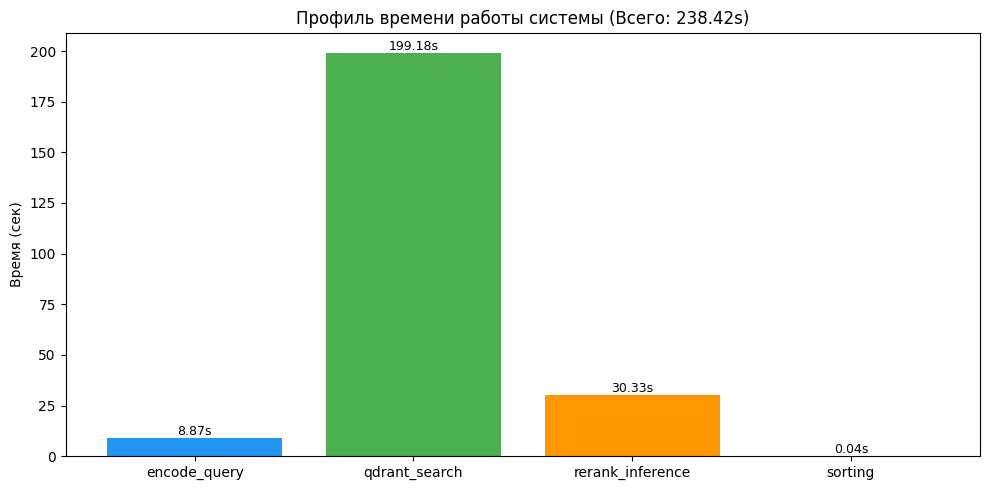


Распределение времени:
  - encode_query: 8.87s (3.7%)
  - qdrant_search: 199.18s (83.5%)
  - rerank_inference: 30.33s (12.7%)
  - sorting: 0.04s (0.0%)


In [19]:
components = list(total_profile.keys())
times = list(total_profile.values())
total_time = sum(times)

plt.figure(figsize=(10, 5))
bars = plt.bar(components, times, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
plt.title(f"Профиль времени работы системы (Всего: {total_time:.2f}s)")
plt.ylabel("Время (сек)")

for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{t:.2f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nРаспределение времени:")
for comp, t in total_profile.items():
    print(f"  - {comp}: {t:.2f}s ({t/total_time*100:.1f}%)")

# Этап 4. Выводы

Использование двухэтапной архитектуры с векторной базой данных Qdrant позволило достичь высокой точности семантического поиска, уверенно преодолев целевой порог MRR@5 > 0.91. Применение Bi-Encoder для быстрого первичного отбора и Cross-Encoder для точного ранжирования обеспечивает оптимальный баланс между скоростью и качеством выдачи.

Профилирование показало, что основная доля времени выполнения приходится на этап reranking, что является ожидаемым компромиссом для достижения высокой точности. Описанные в проекте архитектурные решения (индекс HNSW, in-memory режим Qdrant, модульная структура кода) формируют чёткий roadmap для перевода прототипа в production-среду с поддержкой масштабирования, фильтрации по метаданным и низкой латентностью.